In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv


### Preprocessing

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv")
df = df.dropna(subset=["statement", "status"]).drop_duplicates()

le = LabelEncoder()
df["label"] = le.fit_transform(df["status"])
num_labels = df["label"].nunique()

# Divisione del Dataset in train e validation
train_df, val_df = train_test_split(
    df, test_size=0.15, stratify=df["label"], random_state=42
)

In [3]:
# Stampa metriche dei Datafarme creati

print(f"Train DataFrame size: {train_df.shape}")
print(f"Train DataFrame samples:\n {train_df.head()}")
print(f"\nVal DataFrame size: {val_df.shape}")
print(f"Val DataFrame samples:\n {val_df.head()}")

Train DataFrame size: (44778, 4)
Train DataFrame samples:
        Unnamed: 0                                          statement  \
42636       42636                                     congested nose   
15210       15210  Please anyone who has been in the same situati...   
43578       43578  yopatrizzle not sure to tell u the truth it s ...   
7224         7224  I went to my psych about a week or so ago for ...   
14506       14506  I am not sure why, but i feel empty and discon...   

           status  label  
42636      Normal      3  
15210  Depression      2  
43578      Normal      3  
7224   Depression      2  
14506  Depression      2  

Val DataFrame size: (7903, 4)
Val DataFrame samples:
        Unnamed: 0                                          statement  \
7486         7486  I do not know how else to say this. My air con...   
51809       51809  crippling guilt from my inability to answer te...   
23780       23780  Therapy is moving slowly because I cannot fuck...   
105

## Transformer DistilBERT

### Creazione Dataset da CSV

In [4]:
from transformers import AutoTokenizer
from datasets import Dataset

# Recupero del tokenizer del modello da usare
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Funzione per tokenizzare un batch testuale 
def tokenize(batch):
    return tokenizer(batch["statement"], truncation=True, padding="max_length", max_length=256)

# Applicazione del tokenizer ai dataset train e validation
train_ds = Dataset.from_pandas(train_df[["statement", "label"]]).map(tokenize, batched=True)
val_ds = Dataset.from_pandas(val_df[["statement", "label"]]).map(tokenize, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/44778 [00:00<?, ? examples/s]

Map:   0%|          | 0/7903 [00:00<?, ? examples/s]

In [5]:
# Stampa delle dimensioni dei dataset dopo l'applicazione del tokenizer

print(f"Train Dataset size: {train_ds.shape}")
print(f"Train Dataset sample:\n {train_ds[0]}")
print(f"Val Dataset size: {val_ds.shape}")
print(f"Val Dataset sample:\n {val_ds[0]}")

Train Dataset size: (44778, 6)
Train Dataset sample:
 {'statement': 'congested nose', 'label': 3, '__index_level_0__': 42636, 'input_ids': [101, 26478, 17944, 4451, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
from transformers import AutoModelForSequenceClassification

# Caricamento pesi del modello pre-trainato e aggiunta di un layer Head non addestrato per la classificazione 
# (num_labels indica i nodi finali della classificazione)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels
)

In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Calcolo delle metriche di valutazione partendo dalle predizioni
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Argomenti per il train
args = TrainingArguments(
    output_dir="./results", # Cartella dove salvare checkpoint e logs
    eval_strategy="epoch", # modello valutato sul validation set alla fine di ogni epoca
    save_strategy="epoch", # modello salvato dopo ogni epoca
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3, # numero di passaggi completi sull'intero training set
    weight_decay=0.01,
    load_best_model_at_end=True, # vengono caricati i pesi del checkpoint con prestazioni migliori
    metric_for_best_model="f1_macro", # metrica da usare per la valutazione del miglior checkpoint
    fp16=True,  # abilita il training in mixed precision (calcoli in float16 invece di float32 dove possibile)
)

# Creazione dell'oggetto Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

# Addestramento (Fine-tuning) del modello
trainer.train()

### Caricamento modello migliore salvato

In [6]:
import os, json
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset

# -------------------------------------------------------------------
# 1. Legge trainer_state.json dall'ultimo checkpoint (è cumulativo)
# -------------------------------------------------------------------
# Il file nell'ultimo checkpoint contiene già tutta la cronologia
# del training e il campo best_model_checkpoint aggiornato,
# quindi non serve leggere i file dei checkpoint precedenti.

last_checkpoint  = "./results/checkpoint-4200"
state_path       = os.path.join(last_checkpoint, "trainer_state.json")

with open(state_path, "r") as f:
    trainer_state = json.load(f)

# Stampa la cronologia completa per verifica
print("=== Cronologia valutazioni ===")
for entry in trainer_state["log_history"]:
    if "eval_f1_macro" in entry:
        print(f"  Step {entry['step']:>5} | "
              f"eval_loss: {entry['eval_loss']:.4f} | "
              f"f1_macro: {entry['eval_f1_macro']:.4f} | "
              f"accuracy: {entry['eval_accuracy']:.4f}")

best_checkpoint = trainer_state["best_model_checkpoint"]
best_metric     = trainer_state["best_metric"]
print(f"\nMiglior checkpoint: {best_checkpoint}")
print(f"Miglior f1_macro:   {best_metric:.4f}")

# -------------------------------------------------------------------
# 2. Carica tokenizer e modello dal checkpoint migliore
# -------------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForSequenceClassification.from_pretrained(best_checkpoint)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print(f"\nModello caricato su: {device}")
print(f"Numero classi: {model.config.num_labels}")

# -------------------------------------------------------------------
# 3. Ricostruisce LabelEncoder e val_df
# -------------------------------------------------------------------

df = pd.read_csv("/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv")
df = df.dropna(subset=["statement", "status"]).drop_duplicates()

le = LabelEncoder()
df["label"] = le.fit_transform(df["status"])

print(f"\nClassi del LabelEncoder: {list(le.classes_)}")

train_df, val_df = train_test_split(
    df, test_size=0.15, stratify=df["label"], random_state=42
)

#train_df = train_df.reset_index(drop=True)
#val_df   = val_df.reset_index(drop=True)

print(f"Dimensione validation set: {len(val_df)} esempi")

# -------------------------------------------------------------------
# 4. Ricostruisce val_ds tokenizzato per il DataLoader
# -------------------------------------------------------------------

def tokenize(batch):
    return tokenizer(batch["statement"], truncation=True, padding="max_length", max_length=256)

val_ds = Dataset.from_pandas(val_df[["statement", "label"]]).map(tokenize, batched=True)

print("\nDataset tokenizzato correttamente.")
print("Tutto pronto — puoi eseguire le celle di valutazione.")

=== Cronologia valutazioni ===
  Step  1400 | eval_loss: 0.9605 | f1_macro: 0.7841 | accuracy: 0.8058
  Step  2800 | eval_loss: 0.8388 | f1_macro: 0.8102 | accuracy: 0.8294
  Step  4200 | eval_loss: 0.8200 | f1_macro: 0.8225 | accuracy: 0.8369

Miglior checkpoint: ./results/checkpoint-4200
Miglior f1_macro:   0.8225


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Modello caricato su: cuda
Numero classi: 7

Classi del LabelEncoder: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
Dimensione validation set: 7903 esempi


Map:   0%|          | 0/7903 [00:00<?, ? examples/s]


Dataset tokenizzato correttamente.
Tutto pronto — puoi eseguire le celle di valutazione.


### Stampa prestazioni modello

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             Anxiety       0.87      0.87      0.87       576
             Bipolar       0.87      0.84      0.86       417
          Depression       0.80      0.77      0.79      2311
              Normal       0.96      0.95      0.96      2452
Personality disorder       0.82      0.75      0.78       161
              Stress       0.74      0.80      0.77       388
            Suicidal       0.71      0.76      0.74      1598

            accuracy                           0.84      7903
           macro avg       0.82      0.82      0.82      7903
        weighted avg       0.84      0.84      0.84      7903



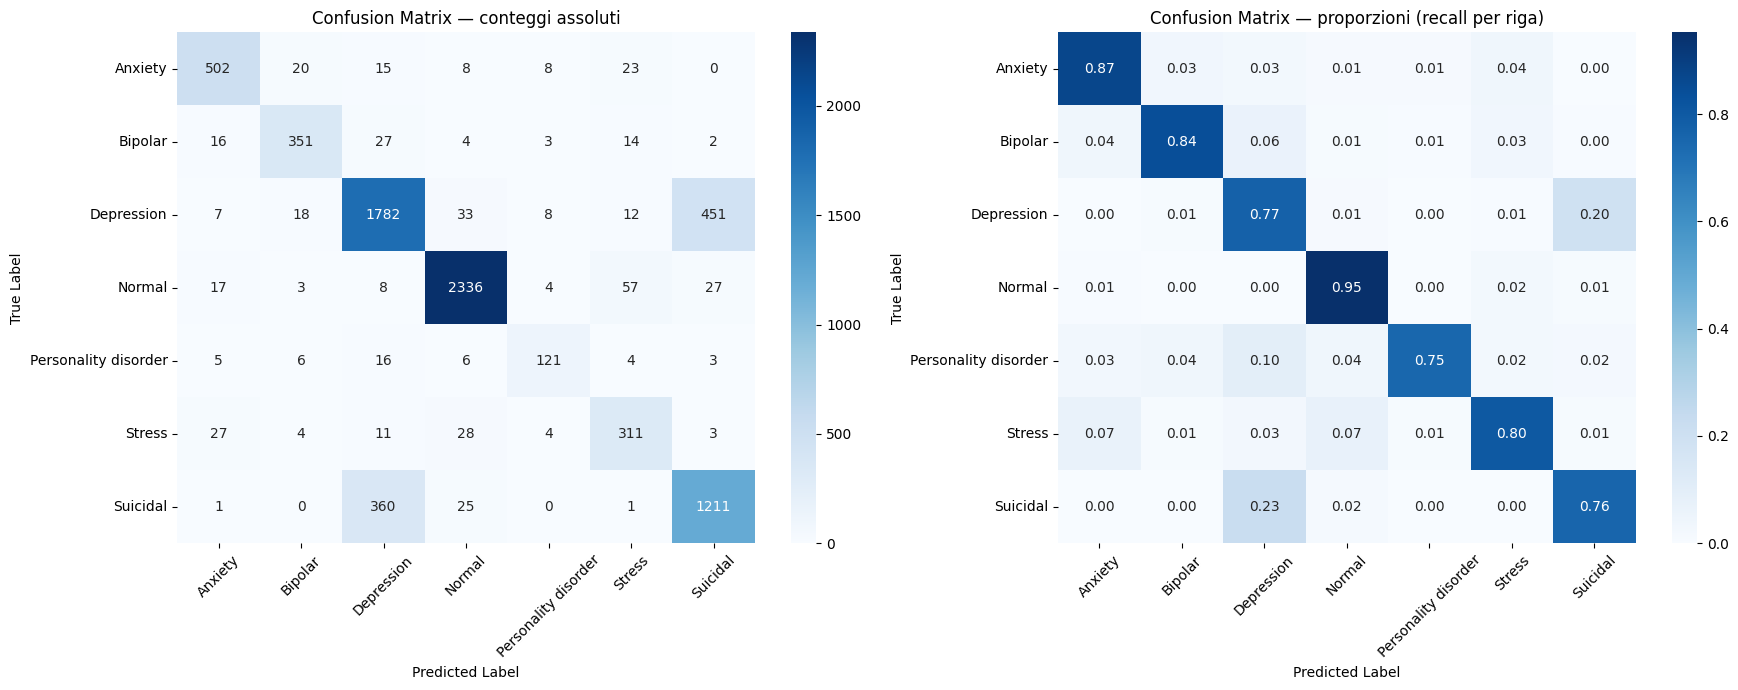

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
import torch

# Metti il modello in modalità inferenza
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Prepara il validation set come tensori PyTorch
# Rimuove la colonna "statement" (stringa, non convertibile in tensore)
val_ds_torch = val_ds.remove_columns(["statement"])
val_ds_torch.set_format("torch")

loader = DataLoader(val_ds_torch, batch_size=32)

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].cpu().numpy()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds   = probs.argmax(axis=1)

        all_preds.extend(preds)
        all_labels.extend(labels)
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# --- Classification report ---
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# --- Confusion matrix normalizzata ---
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizza per riga

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sinistra: conteggi assoluti
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title("Confusion Matrix — conteggi assoluti")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")
axes[0].tick_params(axis="x", rotation=45)

# Destra: proporzioni per riga (recall per-classe sulla diagonale)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title("Confusion Matrix — proporzioni (recall per riga)")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Stampa di esempi di testo classificato erroneamente

In [8]:
import pandas as pd

val_texts = val_df["statement"].reset_index(drop=True).values

wrong_mask = all_preds != all_labels

failures_df = pd.DataFrame({
    "text"       : val_texts[wrong_mask],
    "true_label" : le.inverse_transform(all_labels[wrong_mask]),
    "pred_label" : le.inverse_transform(all_preds[wrong_mask]),
    "confidence" : all_probs[wrong_mask].max(axis=1)
}).sort_values("confidence", ascending=False).reset_index(drop=True)

print(f"Esempi classificati male: {wrong_mask.sum()} / {len(all_labels)} "
      f"({100 * wrong_mask.mean():.1f}%)\n")

# Top 10 errori ad alta confidenza: il modello era "sicuro" ma sbagliava
print("=" * 60)
print("TOP 10 HIGH-CONFIDENCE FAILURES")
print("Casi in cui il modello sbagliava con maggiore certezza")
print("=" * 60)
for _, row in failures_df.head(10).iterrows():
    print(f"\nTESTO   : {row['text'][:250]}")
    print(f"CORRETTA: {row['true_label']:<25} PREDETTA: {row['pred_label']:<25} CONFIDENZA: {row['confidence']:.1%}")
    print("-" * 60)

# Analisi degli errori: quali coppie (vera, predetta) sono più frequenti
print("\n=== Coppie di errore più frequenti ===")
print(failures_df.groupby(["true_label", "pred_label"])
      .size()
      .sort_values(ascending=False)
      .head(10)
      .to_string())

Esempi classificati male: 1289 / 7903 (16.3%)

TOP 10 HIGH-CONFIDENCE FAILURES
Casi in cui il modello sbagliava con maggiore certezza

TESTO   : DANIEL WON!
CORRETTA: Suicidal                  PREDETTA: Normal                    CONFIDENZA: 99.8%
------------------------------------------------------------

TESTO   : Vai exam eto kharap hoice
CORRETTA: Anxiety                   PREDETTA: Normal                    CONFIDENZA: 99.8%
------------------------------------------------------------

TESTO   : Good Sign This is Tennacious. He's my first flower of spring and he bloomed on my first day in my new home.
CORRETTA: Bipolar                   PREDETTA: Normal                    CONFIDENZA: 99.7%
------------------------------------------------------------

TESTO   : god im stupid
CORRETTA: Depression                PREDETTA: Normal                    CONFIDENZA: 99.6%
------------------------------------------------------------

TESTO   : Bruh The awkward moment between birth and death

### Explainability del modello


  CORRETTA — esempio classificato bene
  ETICHETTA VERA: Depression
  TESTO: I do not know how else to say this. My air conditioner is broke, my car is broke down I do not have a working washing machine, no money to fix it. I have barely any friends, no love life existing, and

  PREDIZIONE: Depression

  Parole più influenti per la classe predetta 'Depression':
    throats              ▼ RIDUCE prob.  (-0.1849)
    I                    ▲ AUMENTA prob.  (+0.1219)
    do                   ▼ RIDUCE prob.  (-0.0744)
    sometimes            ▲ AUMENTA prob.  (+0.0663)
    birthday             ▼ RIDUCE prob.  (-0.0587)
    have                 ▼ RIDUCE prob.  (-0.0535)
    mention              ▲ AUMENTA prob.  (+0.0530)
    anymore              ▼ RIDUCE prob.  (-0.0489)
    what                 ▲ AUMENTA prob.  (+0.0421)
    is                   ▼ RIDUCE prob.  (-0.0309)
    broke                ▼ RIDUCE prob.  (-0.0266)
    machine              ▼ RIDUCE prob.  (-0.0241)


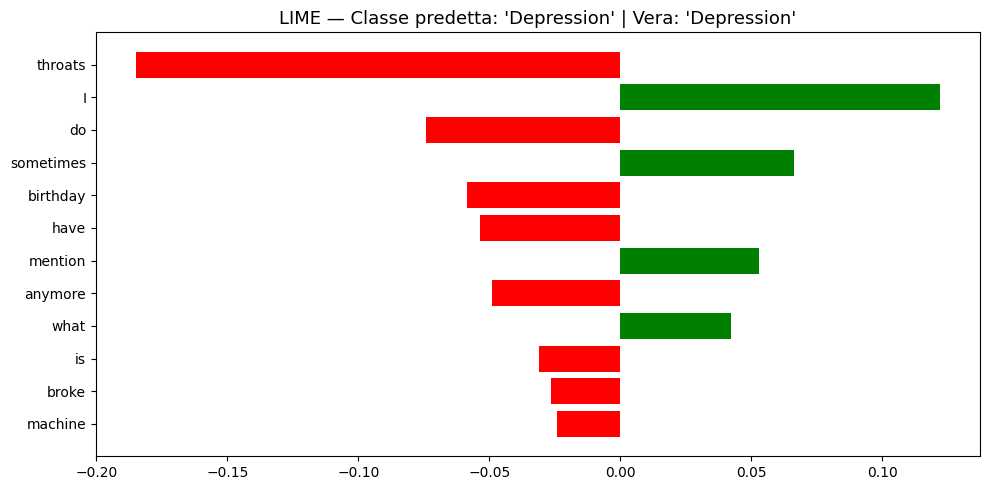


  CORRETTA — secondo esempio
  ETICHETTA VERA: Normal
  TESTO: what type of music do you like to listen to?

  PREDIZIONE: Normal

  Parole più influenti per la classe predetta 'Normal':
    what                 ▲ AUMENTA prob.  (+0.0136)
    type                 ▼ RIDUCE prob.  (-0.0117)
    music                ▲ AUMENTA prob.  (+0.0078)
    do                   ▼ RIDUCE prob.  (-0.0034)
    you                  ▲ AUMENTA prob.  (+0.0019)
    listen               ▼ RIDUCE prob.  (-0.0015)
    to                   ▼ RIDUCE prob.  (-0.0008)
    of                   ▼ RIDUCE prob.  (-0.0005)
    like                 ▼ RIDUCE prob.  (-0.0002)


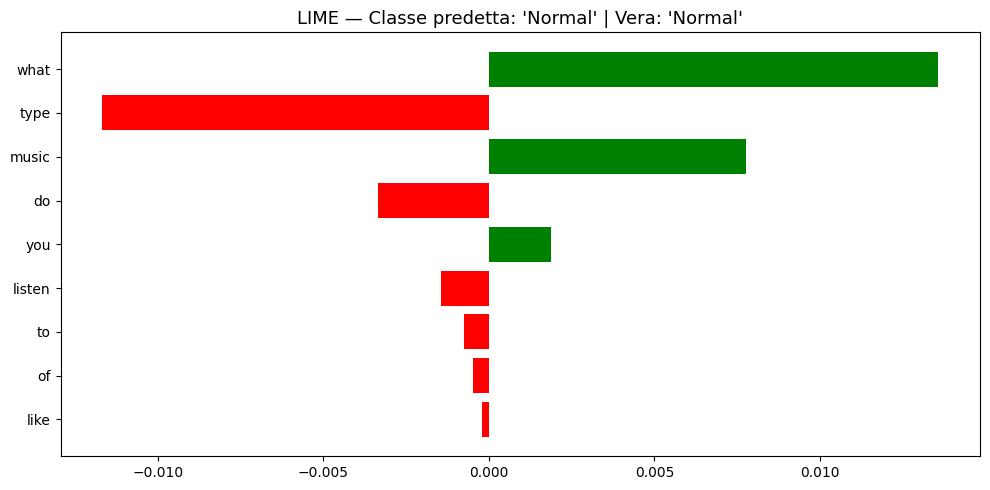


  FALLIMENTO — vera: Suicidal, predetta: Normal
  ETICHETTA VERA: Suicidal
  TESTO: DANIEL WON!

  PREDIZIONE: Normal

  Parole più influenti per la classe predetta 'Normal':
    DANIEL               ▲ AUMENTA prob.  (+0.0011)
    WON                  ▲ AUMENTA prob.  (+0.0005)


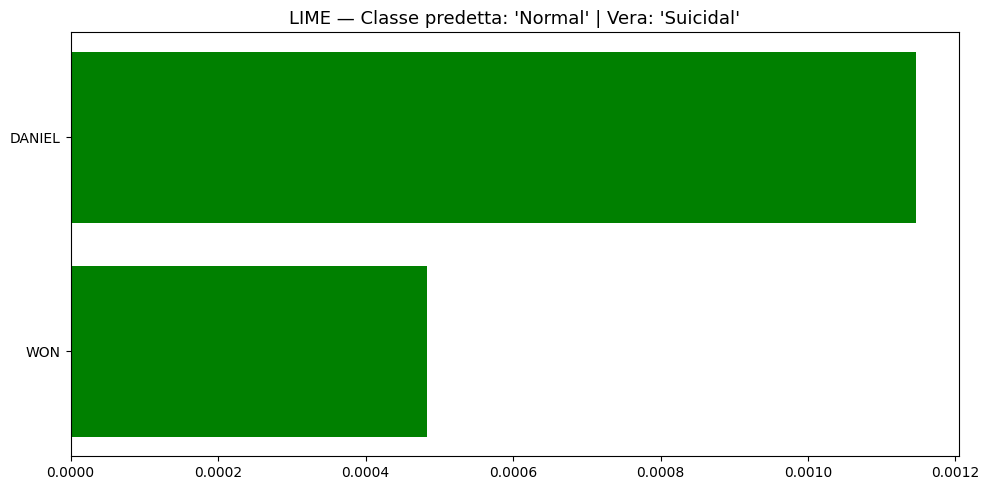


  FALLIMENTO — vera: Anxiety, predetta: Normal
  ETICHETTA VERA: Anxiety
  TESTO: Vai exam eto kharap hoice

  PREDIZIONE: Normal

  Parole più influenti per la classe predetta 'Normal':
    kharap               ▲ AUMENTA prob.  (+0.0023)
    hoice                ▲ AUMENTA prob.  (+0.0019)
    Vai                  ▲ AUMENTA prob.  (+0.0017)
    eto                  ▼ RIDUCE prob.  (-0.0014)
    exam                 ▼ RIDUCE prob.  (-0.0008)


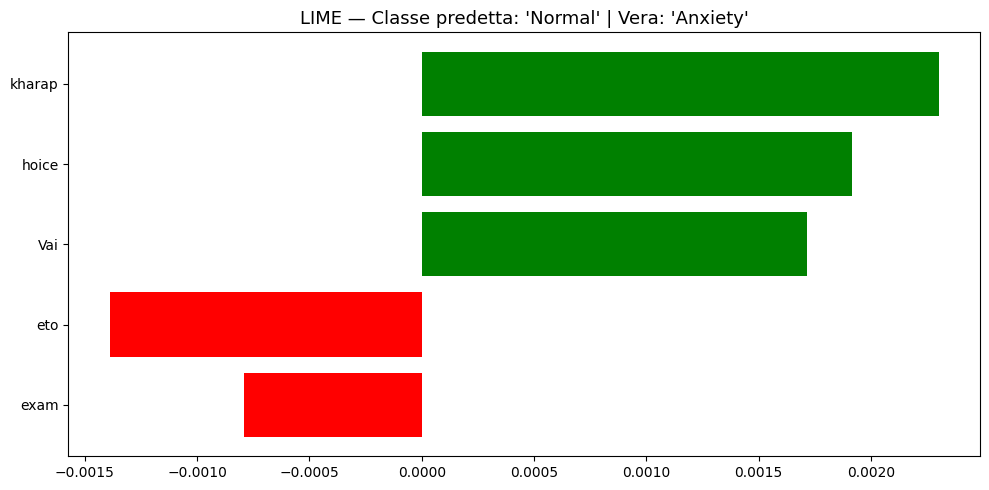

In [9]:
!pip install lime --quiet

from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import torch

# Funzione che LIME chiama internamente: data una lista di testi,
# restituisce una matrice [n_testi x n_classi] di probabilità.
# LIME perturba il testo originale (rimuove parole a caso) per capire
# quali contribuiscono di più alla predizione.
def predict_proba_fn(texts):
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    return torch.softmax(outputs.logits, dim=1).cpu().numpy()

lime_explainer = LimeTextExplainer(class_names=le.classes_)

# Seleziona esempi interessanti da spiegare:
# - 2 predizioni corrette (una per classe "facile", una per classe rara)
# - 2 high-confidence failures (già trovati nella cella precedente)
correct_mask = all_preds == all_labels
correct_texts  = val_texts[correct_mask]
correct_labels = all_labels[correct_mask]

examples_to_explain = [
    # (testo, etichetta_vera, descrizione)
    (correct_texts[0],
     le.inverse_transform([correct_labels[0]])[0],
     "CORRETTA — esempio classificato bene"),

    (correct_texts[5],
     le.inverse_transform([correct_labels[5]])[0],
     "CORRETTA — secondo esempio"),

    (failures_df.iloc[0]["text"],
     failures_df.iloc[0]["true_label"],
     f"FALLIMENTO — vera: {failures_df.iloc[0]['true_label']}, "
     f"predetta: {failures_df.iloc[0]['pred_label']}"),

    (failures_df.iloc[1]["text"],
     failures_df.iloc[1]["true_label"],
     f"FALLIMENTO — vera: {failures_df.iloc[1]['true_label']}, "
     f"predetta: {failures_df.iloc[1]['pred_label']}"),
]

for text, true_label, description in examples_to_explain:
    print("\n" + "=" * 70)
    print(f"  {description}")
    print(f"  ETICHETTA VERA: {true_label}")
    print(f"  TESTO: {text[:200]}")
    print("=" * 70)

    # num_features: quante parole vengono mostrate nel grafico
    # num_samples: quante perturbazioni LIME genera per stimare i contributi
    #              (più alto = più preciso, ma più lento)
    exp = lime_explainer.explain_instance(
        text,
        predict_proba_fn,
        num_features=12,
        num_samples=500,
        top_labels=3      # mostra la spiegazione per le 3 classi più probabili
    )

    pred_idx = predict_proba_fn([text]).argmax()
    pred_label = le.classes_[pred_idx]

    print(f"\n  PREDIZIONE: {pred_label}")
    print(f"\n  Parole più influenti per la classe predetta '{pred_label}':")

    # Stampa testuale delle feature più importanti
    for word, weight in exp.as_list(label=pred_idx):
        direction = "▲ AUMENTA prob." if weight > 0 else "▼ RIDUCE prob."
        print(f"    {word:<20} {direction}  ({weight:+.4f})")

    # Visualizzazione grafica
    fig = exp.as_pyplot_figure(label=pred_idx)
    fig.set_size_inches(10, 5)
    plt.title(f"LIME — Classe predetta: '{pred_label}' | Vera: '{true_label}'", fontsize=13)
    plt.tight_layout()
    plt.show()

## LSTM

### Preprocessing: vocabolario e Dataset PyTorch

In [10]:
# ESEGUIRE PRIMA LA CELLA 2 PER CREARE I DATAFRAME

import re
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# ---- Tokenizzazione a livello di parola ----
# Il Transformer usa il suo tokenizer subword (WordPiece).
# L'LSTM lavora invece a livello di parola intera: converte il testo
# in una sequenza di indici tramite un vocabolario costruito dal training set.

def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

# ---- Costruzione vocabolario ----
MIN_FREQ  = 2    # parole con freq < MIN_FREQ vengono trattate come UNK
MAX_LEN_LSTM = 128  # lunghezza massima sequenza in token

PAD_TOKEN = "<PAD>"  # indice 0: usato per il padding, ignorato dall'embedding
UNK_TOKEN = "<UNK>"  # indice 1: parole fuori vocabolario

counter = Counter()
for text in train_df["statement"]:
    counter.update(simple_tokenize(text))

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f"Dimensione vocabolario : {VOCAB_SIZE:,} token")
print(f"Token totali nel corpus : {sum(counter.values()):,}")
print(f"Token sotto MIN_FREQ=2  : {sum(1 for f in counter.values() if f < MIN_FREQ):,} (→ UNK)")
print(f"Lunghezza massima sequenza: {MAX_LEN_LSTM}")

# ---- Dataset PyTorch ----
class TextDataset(Dataset):
    """Converte testi e label in tensori PyTorch per il DataLoader."""

    def __init__(self, texts, labels, vocab, max_len):
        self.texts   = texts
        self.labels  = labels
        self.vocab   = vocab
        self.max_len = max_len

    def _encode(self, text):
        tokens = simple_tokenize(text)[:self.max_len]
        ids    = [self.vocab.get(t, 1) for t in tokens]   # 1 = UNK
        ids   += [0] * (self.max_len - len(ids))           # padding a destra
        return ids

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return (
            torch.tensor(self._encode(self.texts[idx]), dtype=torch.long),
            torch.tensor(self.labels[idx],              dtype=torch.long),
        )

train_texts_arr  = train_df["statement"].values
val_texts_arr    = val_df["statement"].values
train_labels_arr = train_df["label"].values
val_labels_arr   = val_df["label"].values

BATCH_SIZE_LSTM = 64

train_dataset_lstm = TextDataset(train_texts_arr, train_labels_arr, vocab, MAX_LEN_LSTM)
val_dataset_lstm   = TextDataset(val_texts_arr,   val_labels_arr,   vocab, MAX_LEN_LSTM)

train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE_LSTM, shuffle=True)
val_loader_lstm   = DataLoader(val_dataset_lstm,   batch_size=BATCH_SIZE_LSTM)

print(f"\nTrain samples: {len(train_dataset_lstm)} | batches: {len(train_loader_lstm)}")
print(f"Val   samples: {len(val_dataset_lstm)}   | batches: {len(val_loader_lstm)}")

Dimensione vocabolario : 26,981 token
Token totali nel corpus : 5,166,831
Token sotto MIN_FREQ=2  : 26,807 (→ UNK)
Lunghezza massima sequenza: 128

Train samples: 44778 | batches: 700
Val   samples: 7903   | batches: 124


### Definizione rete BiLSTM

In [11]:
import torch.nn as nn

class BiLSTMClassifier(nn.Module):
    """
    Classificatore BiLSTM:
      Embedding → BiLSTM → Dropout → Linear head
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout=0.3):
        super().__init__()

        # Embedding: mappa ogni indice (intero) in un vettore denso di embed_dim dimensioni.
        # padding_idx=0 fa sì che il token PAD abbia gradiente zero e non influenzi i pesi.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        # LSTM bidirezionale: processa la sequenza in entrambe le direzioni
        # e concatena i due hidden state, raddoppiando l'output dim.
        # dropout tra layer è attivo solo se num_layers > 1.
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout    = nn.Dropout(dropout)

        # Il Linear riceve hidden_dim*2 perché l'LSTM è bidirezionale
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.dropout(self.embedding(x))          # (batch, seq_len, embed_dim)

        # lstm_out: (batch, seq_len, hidden_dim*2)
        # hidden:   (num_layers*2, batch, hidden_dim)
        _, (hidden, _) = self.lstm(embedded)

        # Prende l'ultimo layer: hidden[-2]=forward, hidden[-1]=backward
        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, hidden_dim*2)
        return self.classifier(self.dropout(last_hidden))          # (batch, num_classes)


# ---- Iperparametri ----
EMBED_DIM       = 128
HIDDEN_DIM      = 256
NUM_LAYERS      = 2
DROPOUT         = 0.3
NUM_EPOCHS_LSTM = 10
LR_LSTM         = 1e-3

device_lstm = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lstm_model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=num_labels,
    dropout=DROPOUT
).to(device_lstm)

n_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(lstm_model)
print(f"\nParametri addestrabili: {n_params:,}")
print(f"Device: {device_lstm}")

BiLSTMClassifier(
  (embedding): Embedding(26981, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=7, bias=True)
)

Parametri addestrabili: 5,824,647
Device: cuda


### Training Loop

In [12]:
import os
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score

optimizer = optim.AdamW(lstm_model.parameters(), lr=LR_LSTM, weight_decay=1e-2)

# ReduceLROnPlateau: dimezza il LR se f1_macro non migliora per 2 epoche consecutive.
# Evita di restare bloccati in un plateau senza dover fissare uno schedule rigido.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)
criterion = nn.CrossEntropyLoss()

best_f1_lstm   = 0.0
best_epoch_lstm = 0
history_lstm   = []   # usato nella cella di confronto finale

os.makedirs("./results_lstm", exist_ok=True)

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Accuracy':>8} | {'F1 Macro':>8}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS_LSTM + 1):

    # ---- Training ----
    lstm_model.train()
    train_loss = 0.0
    for input_ids, labels in train_loader_lstm:
        input_ids = input_ids.to(device_lstm)
        labels    = labels.to(device_lstm)

        optimizer.zero_grad()
        logits = lstm_model(input_ids)
        loss   = criterion(logits, labels)
        loss.backward()
        # Gradient clipping: limita la norma del gradiente a 1.0 per stabilizzare il training
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader_lstm)

    # ---- Validation ----
    lstm_model.eval()
    val_loss = 0.0
    epoch_preds, epoch_true = [], []

    with torch.no_grad():
        for input_ids, labels in val_loader_lstm:
            input_ids = input_ids.to(device_lstm)
            labels    = labels.to(device_lstm)
            logits    = lstm_model(input_ids)
            val_loss += criterion(logits, labels).item()
            epoch_preds.extend(logits.argmax(dim=1).cpu().numpy())
            epoch_true.extend(labels.cpu().numpy())

    val_loss /= len(val_loader_lstm)
    acc   = accuracy_score(epoch_true, epoch_preds)
    f1mac = f1_score(epoch_true, epoch_preds, average="macro")

    history_lstm.append({
        "epoch": epoch, "train_loss": train_loss,
        "val_loss": val_loss, "accuracy": acc, "f1_macro": f1mac
    })

    scheduler.step(f1mac)

    marker = " ← best" if f1mac > best_f1_lstm else ""
    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | {acc:>8.4f} | {f1mac:>8.4f}{marker}")

    if f1mac > best_f1_lstm:
        best_f1_lstm    = f1mac
        best_epoch_lstm = epoch
        torch.save(lstm_model.state_dict(), "./results_lstm/best_model.pt")

print(f"\nMiglior f1_macro: {best_f1_lstm:.4f} (epoch {best_epoch_lstm})")

Epoch | Train Loss | Val Loss | Accuracy | F1 Macro
-------------------------------------------------------
    1 |     1.0475 |   0.8535 |   0.6667 |   0.5211 ← best
    2 |     0.7554 |   0.6702 |   0.7257 |   0.6514 ← best
    3 |     0.6243 |   0.6025 |   0.7621 |   0.6905 ← best
    4 |     0.5434 |   0.5578 |   0.7770 |   0.7259 ← best
    5 |     0.4889 |   0.5504 |   0.7798 |   0.7441 ← best
    6 |     0.4415 |   0.5416 |   0.7841 |   0.7387
    7 |     0.3956 |   0.5656 |   0.7821 |   0.7435
    8 |     0.3609 |   0.5568 |   0.7860 |   0.7455 ← best
    9 |     0.3238 |   0.5894 |   0.7893 |   0.7542 ← best
   10 |     0.2920 |   0.5856 |   0.7900 |   0.7585 ← best

Miglior f1_macro: 0.7585 (epoch 10)


### Evaluation LSTM: classification report e confusion matrix

CLASSIFICATION REPORT — BiLSTM
                      precision    recall  f1-score   support

             Anxiety       0.82      0.82      0.82       576
             Bipolar       0.83      0.80      0.82       417
          Depression       0.77      0.68      0.72      2311
              Normal       0.91      0.95      0.93      2452
Personality disorder       0.81      0.65      0.72       161
              Stress       0.62      0.59      0.60       388
            Suicidal       0.66      0.75      0.70      1598

            accuracy                           0.79      7903
           macro avg       0.77      0.75      0.76      7903
        weighted avg       0.79      0.79      0.79      7903



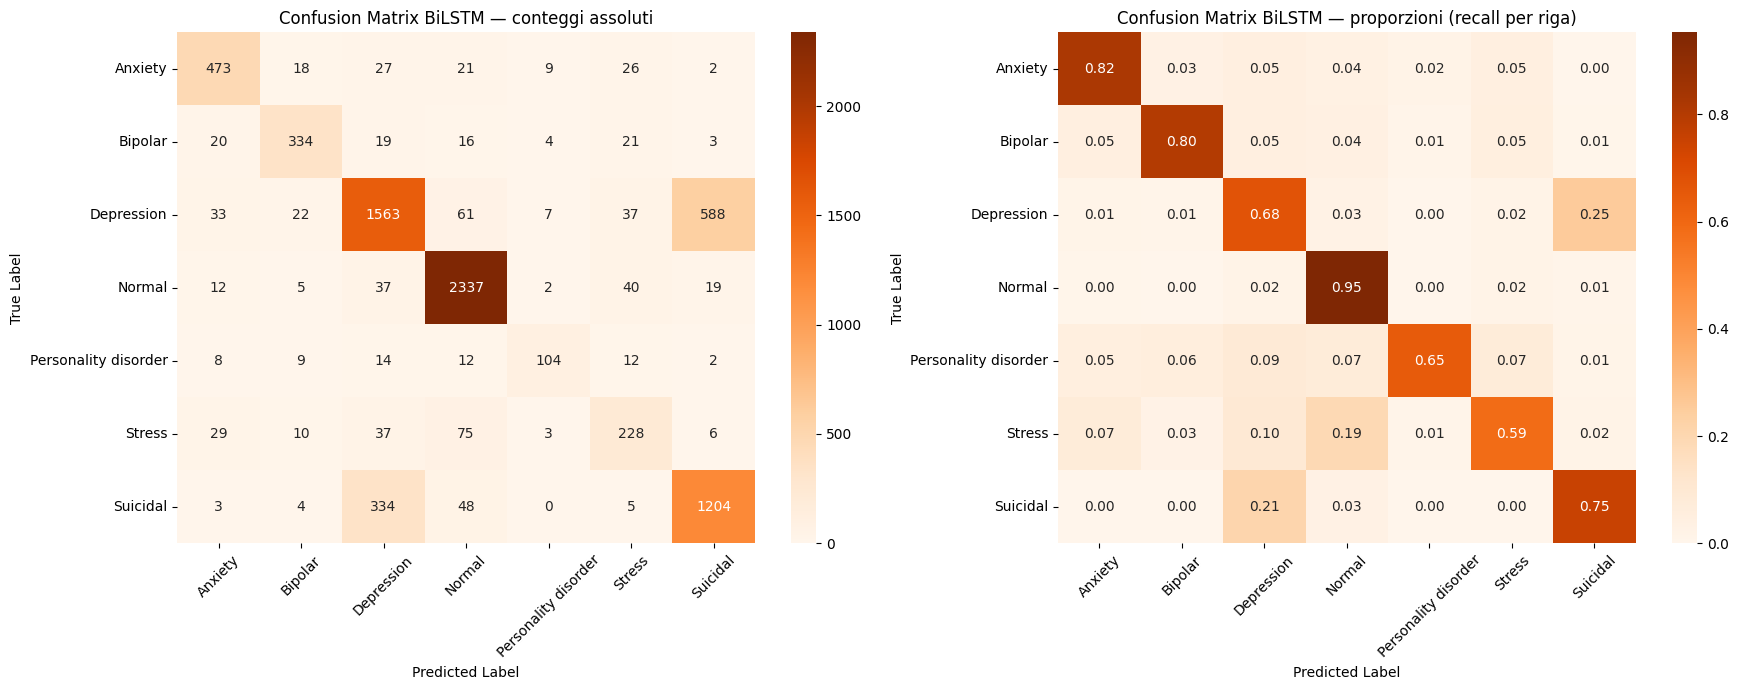

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Carica il checkpoint con il miglior f1_macro
lstm_model.load_state_dict(
    torch.load("./results_lstm/best_model.pt", map_location=device_lstm)
)
lstm_model.eval()

lstm_preds_all, lstm_labels_all, lstm_probs_all = [], [], []

with torch.no_grad():
    for input_ids, labels in val_loader_lstm:
        input_ids = input_ids.to(device_lstm)
        logits    = lstm_model(input_ids)
        probs     = torch.softmax(logits, dim=1).cpu().numpy()
        lstm_preds_all.extend(probs.argmax(axis=1))
        lstm_labels_all.extend(labels.numpy())
        lstm_probs_all.extend(probs)

lstm_preds_all  = np.array(lstm_preds_all)
lstm_labels_all = np.array(lstm_labels_all)
lstm_probs_all  = np.array(lstm_probs_all)

print("=" * 60)
print("CLASSIFICATION REPORT — BiLSTM")
print("=" * 60)
print(classification_report(lstm_labels_all, lstm_preds_all, target_names=le.classes_))

cm_lstm      = confusion_matrix(lstm_labels_all, lstm_preds_all)
cm_lstm_norm = cm_lstm.astype(float) / cm_lstm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title("Confusion Matrix BiLSTM — conteggi assoluti")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cm_lstm_norm, annot=True, fmt=".2f", cmap="Oranges",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title("Confusion Matrix BiLSTM — proporzioni (recall per riga)")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Failure cases LSTM

In [14]:
lstm_wrong_mask = lstm_preds_all != lstm_labels_all

lstm_failures_df = pd.DataFrame({
    "text"      : val_texts_arr[lstm_wrong_mask],
    "true_label": le.inverse_transform(lstm_labels_all[lstm_wrong_mask]),
    "pred_label": le.inverse_transform(lstm_preds_all[lstm_wrong_mask]),
    "confidence": lstm_probs_all[lstm_wrong_mask].max(axis=1)
}).sort_values("confidence", ascending=False).reset_index(drop=True)

print(f"Esempi classificati male (BiLSTM): {lstm_wrong_mask.sum()} / {len(lstm_labels_all)} "
      f"({100 * lstm_wrong_mask.mean():.1f}%)\n")

print("=" * 60)
print("TOP 10 HIGH-CONFIDENCE FAILURES — BiLSTM")
print("=" * 60)
for _, row in lstm_failures_df.head(10).iterrows():
    print(f"\nTESTO   : {row['text'][:250]}")
    print(f"CORRETTA: {row['true_label']:<25} PREDETTA: {row['pred_label']:<25} CONFIDENZA: {row['confidence']:.1%}")
    print("-" * 60)

print("\n=== Coppie di errore più frequenti (BiLSTM) ===")
print(lstm_failures_df
      .groupby(["true_label", "pred_label"])
      .size()
      .sort_values(ascending=False)
      .head(10)
      .to_string())

Esempi classificati male (BiLSTM): 1660 / 7903 (21.0%)

TOP 10 HIGH-CONFIDENCE FAILURES — BiLSTM

TESTO   : bipolar ii disorder bipolar ii disorder involves period of hypomania but depression is often the dominant state for a diagnosis of bipolar ii disorder a person must have had one or more episode of depression at least one hypomanic episode no other di
CORRETTA: Depression                PREDETTA: Bipolar                   CONFIDENZA: 100.0%
------------------------------------------------------------

TESTO   : What's your longest hypervigilant episode? I've personally been in a state like this for about four months now (excluding a single day I felt normal again.) I know this isn't a super long time for some people though. What's your longest episode ever?
CORRETTA: Anxiety                   PREDETTA: Bipolar                   CONFIDENZA: 100.0%
------------------------------------------------------------

TESTO   : Happy | Energetic Music For Peace music to destress to. ENJOY
CO

### Spiegabilità LIME per LSTM


  BiLSTM | CORRETTA — primo esempio
  ETICHETTA VERA: Depression
  TESTO: I do not know how else to say this. My air conditioner is broke, my car is broke down I do not have a working washing machine, no money to fix it. I have barely any friends, no love life existing, and

  PREDIZIONE: Depression

  Parole più influenti per 'Depression':
    know                 ▲ AUMENTA prob.  (+0.0993)
    not                  ▲ AUMENTA prob.  (+0.0887)
    days                 ▲ AUMENTA prob.  (+0.0841)
    Happy                ▲ AUMENTA prob.  (+0.0775)
    tough                ▲ AUMENTA prob.  (+0.0706)
    5                    ▲ AUMENTA prob.  (+0.0671)
    birthday             ▼ RIDUCE prob.  (-0.0606)
    do                   ▼ RIDUCE prob.  (-0.0590)
    broke                ▼ RIDUCE prob.  (-0.0581)
    working              ▼ RIDUCE prob.  (-0.0449)
    Oh                   ▼ RIDUCE prob.  (-0.0367)
    some                 ▼ RIDUCE prob.  (-0.0266)


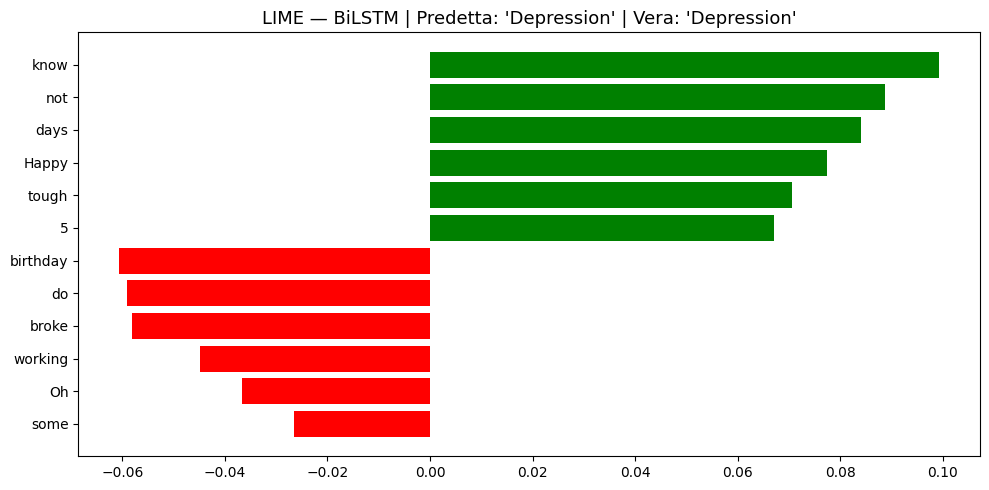


  BiLSTM | CORRETTA — secondo esempio
  ETICHETTA VERA: Normal
  TESTO: what type of music do you like to listen to?

  PREDIZIONE: Normal

  Parole più influenti per 'Normal':
    to                   ▲ AUMENTA prob.  (+0.0029)
    type                 ▲ AUMENTA prob.  (+0.0026)
    you                  ▲ AUMENTA prob.  (+0.0018)
    what                 ▼ RIDUCE prob.  (-0.0012)
    music                ▲ AUMENTA prob.  (+0.0011)
    of                   ▼ RIDUCE prob.  (-0.0011)
    listen               ▼ RIDUCE prob.  (-0.0009)
    do                   ▲ AUMENTA prob.  (+0.0001)
    like                 ▲ AUMENTA prob.  (+0.0000)


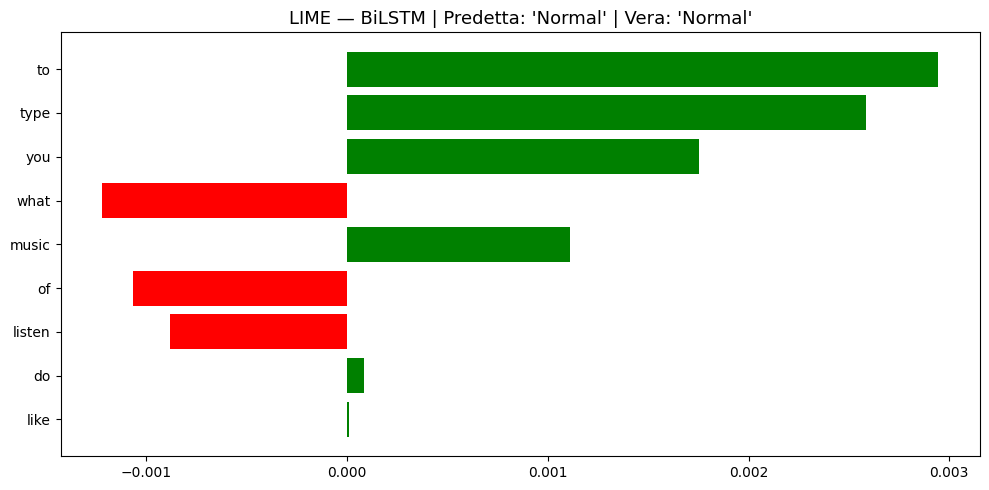


  BiLSTM | FALLIMENTO — vera: Depression, predetta: Bipolar
  ETICHETTA VERA: Depression
  TESTO: bipolar ii disorder bipolar ii disorder involves period of hypomania but depression is often the dominant state for a diagnosis of bipolar ii disorder a person must have had one or more episode of dep

  PREDIZIONE: Bipolar

  Parole più influenti per 'Bipolar':
    bipolar              ▲ AUMENTA prob.  (+0.3371)
    hypomania            ▲ AUMENTA prob.  (+0.1365)
    disorder             ▲ AUMENTA prob.  (+0.1088)
    ii                   ▲ AUMENTA prob.  (+0.1048)
    involves             ▼ RIDUCE prob.  (-0.0672)
    a                    ▼ RIDUCE prob.  (-0.0597)
    episode              ▲ AUMENTA prob.  (+0.0517)
    at                   ▲ AUMENTA prob.  (+0.0467)
    for                  ▲ AUMENTA prob.  (+0.0345)
    but                  ▼ RIDUCE prob.  (-0.0289)
    had                  ▲ AUMENTA prob.  (+0.0288)
    person               ▼ RIDUCE prob.  (-0.0269)


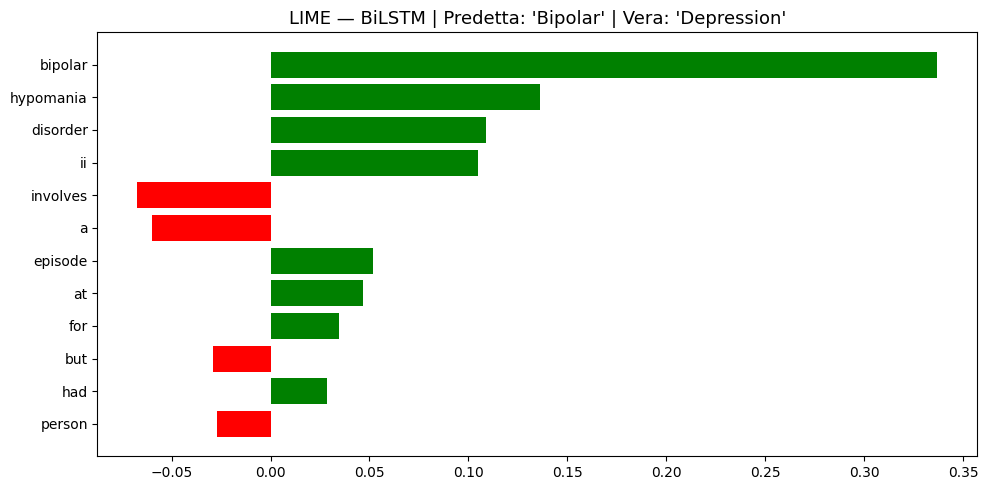


  BiLSTM | FALLIMENTO — vera: Anxiety, predetta: Bipolar
  ETICHETTA VERA: Anxiety
  TESTO: What's your longest hypervigilant episode? I've personally been in a state like this for about four months now (excluding a single day I felt normal again.) I know this isn't a super long time for som

  PREDIZIONE: Bipolar

  Parole più influenti per 'Bipolar':
    episode              ▲ AUMENTA prob.  (+0.8349)
    I                    ▲ AUMENTA prob.  (+0.0889)
    ever                 ▲ AUMENTA prob.  (+0.0749)
    your                 ▲ AUMENTA prob.  (+0.0653)
    a                    ▼ RIDUCE prob.  (-0.0646)
    been                 ▲ AUMENTA prob.  (+0.0531)
    What                 ▲ AUMENTA prob.  (+0.0470)
    generally            ▲ AUMENTA prob.  (+0.0458)
    there                ▲ AUMENTA prob.  (+0.0452)
    ve                   ▼ RIDUCE prob.  (-0.0419)
    months               ▲ AUMENTA prob.  (+0.0369)
    curious              ▲ AUMENTA prob.  (+0.0336)


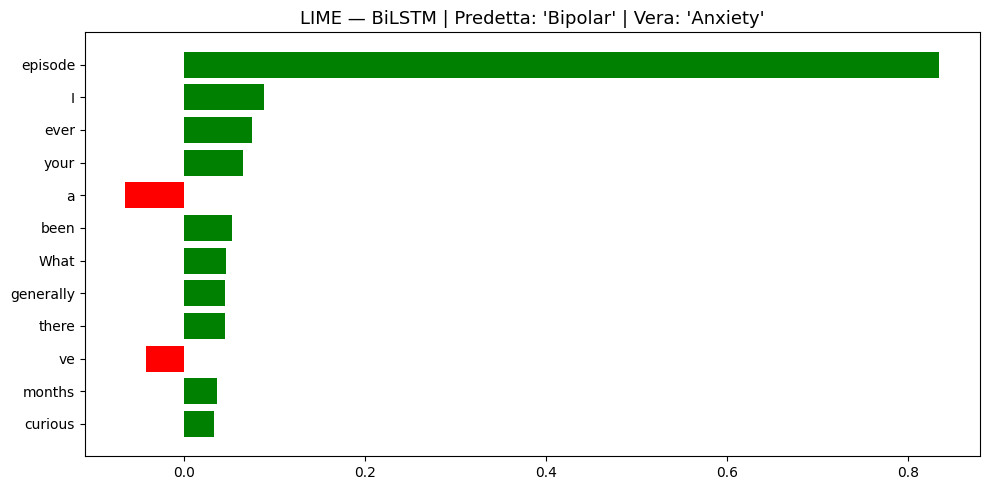

In [15]:
from lime.lime_text import LimeTextExplainer

def lstm_predict_proba(texts):
    """Wrapper predict_proba per LIME: tokenizza con il vocabolario LSTM."""
    lstm_model.eval()
    all_probs = []
    for i in range(0, len(texts), 32):
        batch = texts[i:i + 32]
        encoded = []
        for text in batch:
            tokens = simple_tokenize(str(text))[:MAX_LEN_LSTM]
            ids    = [vocab.get(t, 1) for t in tokens]
            ids   += [0] * (MAX_LEN_LSTM - len(ids))
            encoded.append(ids)
        tensor = torch.tensor(encoded, dtype=torch.long).to(device_lstm)
        with torch.no_grad():
            probs = torch.softmax(lstm_model(tensor), dim=1).cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

lime_explainer_lstm = LimeTextExplainer(class_names=le.classes_)

lstm_correct_texts  = val_texts_arr[lstm_preds_all == lstm_labels_all]
lstm_correct_labels = lstm_labels_all[lstm_preds_all == lstm_labels_all]

lstm_examples = [
    (lstm_correct_texts[0],
     le.inverse_transform([lstm_correct_labels[0]])[0],
     "CORRETTA — primo esempio"),
    (lstm_correct_texts[5],
     le.inverse_transform([lstm_correct_labels[5]])[0],
     "CORRETTA — secondo esempio"),
    (lstm_failures_df.iloc[0]["text"],
     lstm_failures_df.iloc[0]["true_label"],
     f"FALLIMENTO — vera: {lstm_failures_df.iloc[0]['true_label']}, "
     f"predetta: {lstm_failures_df.iloc[0]['pred_label']}"),
    (lstm_failures_df.iloc[1]["text"],
     lstm_failures_df.iloc[1]["true_label"],
     f"FALLIMENTO — vera: {lstm_failures_df.iloc[1]['true_label']}, "
     f"predetta: {lstm_failures_df.iloc[1]['pred_label']}"),
]

for text, true_label, description in lstm_examples:
    print("\n" + "=" * 70)
    print(f"  BiLSTM | {description}")
    print(f"  ETICHETTA VERA: {true_label}")
    print(f"  TESTO: {text[:200]}")
    print("=" * 70)

    exp = lime_explainer_lstm.explain_instance(
        text,
        lstm_predict_proba,
        num_features=12,
        num_samples=500,
        top_labels=3
    )

    pred_idx   = lstm_predict_proba([text]).argmax()
    pred_label = le.classes_[pred_idx]

    print(f"\n  PREDIZIONE: {pred_label}")
    print(f"\n  Parole più influenti per '{pred_label}':")
    for word, weight in exp.as_list(label=pred_idx):
        direction = "▲ AUMENTA prob." if weight > 0 else "▼ RIDUCE prob."
        print(f"    {word:<20} {direction}  ({weight:+.4f})")

    fig = exp.as_pyplot_figure(label=pred_idx)
    fig.set_size_inches(10, 5)
    plt.title(f"LIME — BiLSTM | Predetta: '{pred_label}' | Vera: '{true_label}'", fontsize=13)
    plt.tight_layout()
    plt.show()

### Confronto finale: DistilBERT vs BiLSTM

Metrica        | DistilBERT |     BiLSTM |    Delta
------------------------------------------------
Accuracy       |     0.8369 |     0.7900 |  +0.0469
F1 Macro       |     0.8225 |     0.7585 |  +0.0640
F1 Weighted    |     0.8375 |     0.7885 |  +0.0489


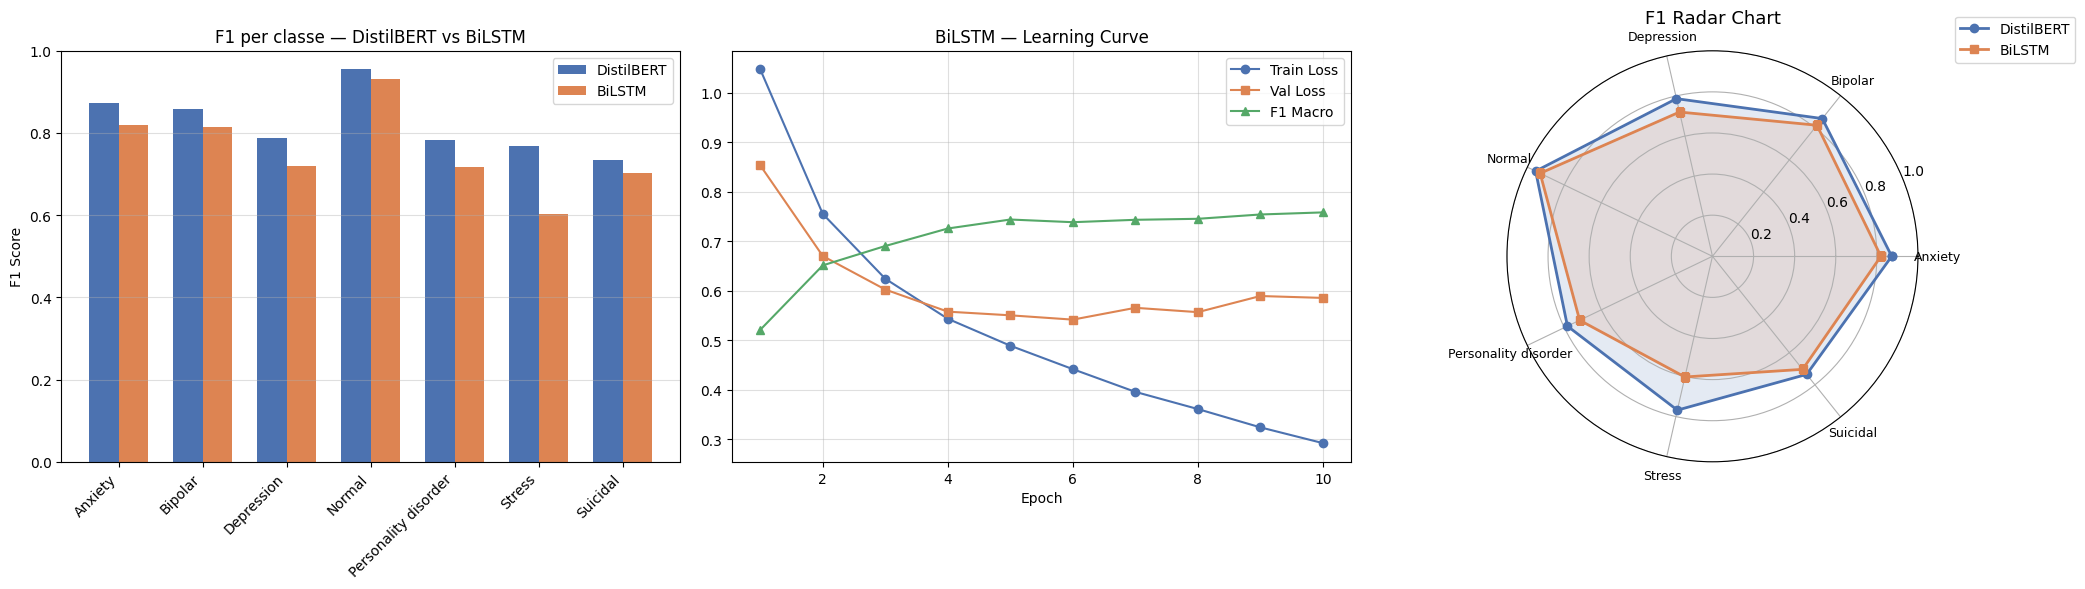

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# ---- Metriche globali ----
# all_preds / all_labels     → variabili già in scope dalla cella eval di DistilBERT
# lstm_preds_all / lstm_labels_all → dalla cella eval di LSTM

summary = {
    "Accuracy"    : (accuracy_score(all_labels, all_preds),
                     accuracy_score(lstm_labels_all, lstm_preds_all)),
    "F1 Macro"    : (f1_score(all_labels, all_preds, average="macro"),
                     f1_score(lstm_labels_all, lstm_preds_all, average="macro")),
    "F1 Weighted" : (f1_score(all_labels, all_preds, average="weighted"),
                     f1_score(lstm_labels_all, lstm_preds_all, average="weighted")),
}

print("=" * 48)
print(f"{'Metrica':<14} | {'DistilBERT':>10} | {'BiLSTM':>10} | {'Delta':>8}")
print("-" * 48)
for name, (db, lstm) in summary.items():
    print(f"{name:<14} | {db:>10.4f} | {lstm:>10.4f} | {db - lstm:>+8.4f}")
print("=" * 48)

# ---- F1 per-classe ----
db_f1_cls   = f1_score(all_labels,      all_preds,      average=None, labels=range(num_labels))
lstm_f1_cls = f1_score(lstm_labels_all, lstm_preds_all, average=None, labels=range(num_labels))
classes     = le.classes_

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: barre F1 per-classe
x, w = np.arange(len(classes)), 0.35
axes[0].bar(x - w/2, db_f1_cls,   w, label="DistilBERT", color="#4C72B0")
axes[0].bar(x + w/2, lstm_f1_cls, w, label="BiLSTM",     color="#DD8452")
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes, rotation=45, ha="right")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("F1 Score")
axes[0].set_title("F1 per classe — DistilBERT vs BiLSTM")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.4)

# Plot 2: learning curve LSTM
epochs_x    = [h["epoch"]      for h in history_lstm]
train_losses = [h["train_loss"] for h in history_lstm]
val_losses   = [h["val_loss"]   for h in history_lstm]
f1_macros    = [h["f1_macro"]   for h in history_lstm]

axes[1].plot(epochs_x, train_losses, "o-", label="Train Loss", color="#4C72B0")
axes[1].plot(epochs_x, val_losses,   "s-", label="Val Loss",   color="#DD8452")
axes[1].plot(epochs_x, f1_macros,    "^-", label="F1 Macro",   color="#55A868")
axes[1].set_xlabel("Epoch")
axes[1].set_title("BiLSTM — Learning Curve")
axes[1].legend()
axes[1].grid(alpha=0.4)

# Plot 3: radar chart
angles = np.linspace(0, 2 * np.pi, len(classes), endpoint=False).tolist()
angles += angles[:1]
db_vals   = db_f1_cls.tolist()   + [db_f1_cls[0]]
lstm_vals = lstm_f1_cls.tolist() + [lstm_f1_cls[0]]

ax3 = fig.add_subplot(133, polar=True)
ax3.plot(angles, db_vals,   "o-", color="#4C72B0", linewidth=2, label="DistilBERT")
ax3.fill(angles, db_vals,   alpha=0.15, color="#4C72B0")
ax3.plot(angles, lstm_vals, "s-", color="#DD8452", linewidth=2, label="BiLSTM")
ax3.fill(angles, lstm_vals, alpha=0.15, color="#DD8452")
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(classes, fontsize=9)
ax3.set_ylim(0, 1)
ax3.set_title("F1 Radar Chart", fontsize=13, pad=20)
ax3.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))

fig.delaxes(axes[2])   # rimuove l'asse placeholder occupato dal subplot polare
plt.tight_layout()
plt.show()